In [2]:
# standard library
import os
import glob
import random
from collections import Counter

# data handling
import pandas as pd

# image processing
from PIL import Image
import cv2

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# deep learning
import torch
from facenet_pytorch import MTCNN

# utilities
from tqdm import tqdm



In [1]:
classes = ['realperson', 'fake_mask', 'fake_printed', 'fake_screen', 'fake_mannequin', 'fake_unknown']

TRAIN_PATH = "../data/cropped"
TEST_PATH  = "../data/cropped_test"

## <b>1) overview dataset</b>
> - data train didominasi oleh kelas fake (~73%) imbalance <br>
> - format gambar didominasi oleh .jpg di train dan test

### <h4 style="color:blue;">Distribusi Kelas: Fake vs Real</h5>

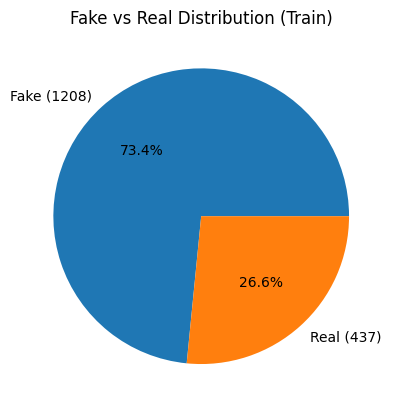

Total rows: 1645


In [8]:
def count_images(base_path):
    counts = {}
    
    for cls in classes:
        folder = os.path.join(base_path, cls)
        
        if not os.path.exists(folder):
            counts[cls] = 0
            continue
        
        counts[cls] = len(os.listdir(folder))
    
    return counts

# ambil dari TRAIN
counts = count_images(TRAIN_PATH)

real = counts['realperson']
fake = sum([counts[c] for c in classes if c != 'realperson'])

labels = [f'Fake ({fake})', f'Real ({real})']
sizes = [fake, real]

plt.figure()
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('Fake vs Real Distribution (Train)')
plt.show()

print("Total rows:", fake + real)

### <h4 style="color:blue;">Distribusi Format File pada Dataset (Train vs Test)</h5>

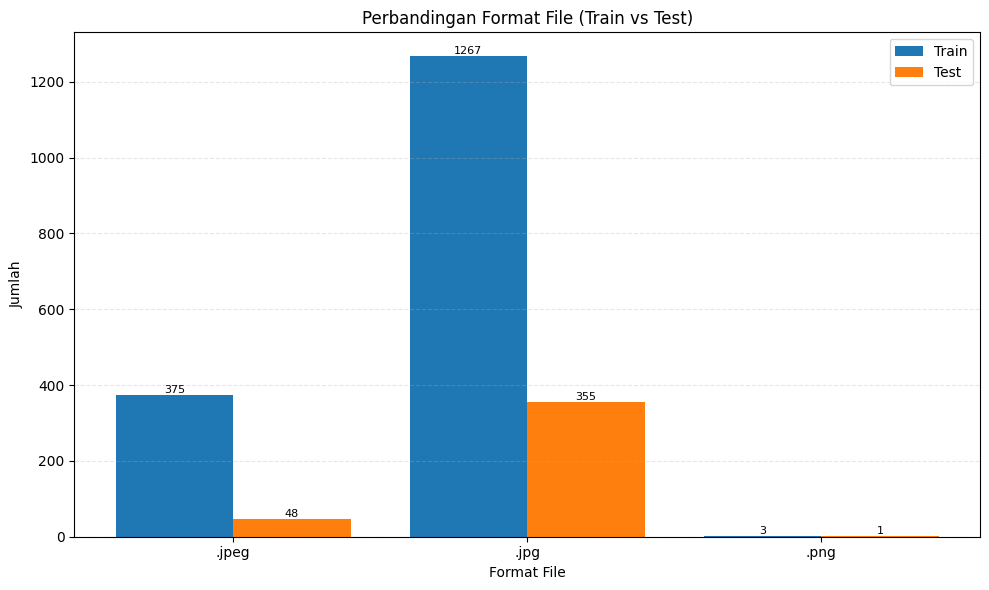

In [10]:
# ada format apa aja?

def count_formats(directory):
    counter = Counter()
    
    for root, _, files in os.walk(directory):
        for file in files:
            ext = os.path.splitext(file)[1].lower()
            if ext:  # skip kalau ga ada extension
                counter[ext] += 1
                
    return counter

# hitung
train_formats = count_formats(TRAIN_PATH)
test_formats  = count_formats(TEST_PATH)

all_formats = sorted(set(train_formats) | set(test_formats))

train_counts = [train_formats.get(f, 0) for f in all_formats]
test_counts  = [test_formats.get(f, 0) for f in all_formats]

x = range(len(all_formats))
width = 0.4

# plot
plt.figure(figsize=(10, 6))

bars1 = plt.bar([i - width/2 for i in x], train_counts, width, label='Train')
bars2 = plt.bar([i + width/2 for i in x], test_counts,  width, label='Test')

plt.xticks(x, all_formats)
plt.xlabel("Format File")
plt.ylabel("Jumlah")
plt.title("Perbandingan Format File (Train vs Test)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

# label angka
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h, str(int(h)),
                 ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## <b>2) visual inspect</b>
> - data train didominasi oleh kelas fake (~73%) imbalance <br>
> - format gambar didominasi oleh .jpg di train dan test

### <h4 style="color:blue;">Distribusi Ukuran Gambar per Kelas</h5>

In [ ]:
MAX_IMAGES = 300  # batasi biar ga crash

for cls in classes:
    cls_path = os.path.join(TRAIN_PATH, cls)

    if not os.path.exists(cls_path):
        continue

    shapes = []

    files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]

    for file in files[:MAX_IMAGES]:  # 🔥 limit di sini
        img_path = os.path.join(cls_path, file)

        img = cv2.imread(img_path)
        if img is None:
            continue

        h, w = img.shape[:2]
        shapes.append((h, w))

    if len(shapes) == 0:
        continue

    shapes = pd.DataFrame(shapes, columns=['Height', 'Width'])

    plt.figure(figsize=(8, 5))
    
    sns.kdeplot(shapes['Height'], bw_adjust=0.5, label='Height')
    sns.kdeplot(shapes['Width'], bw_adjust=0.5, label='Width')

    plt.title(f'Distribution of Image Sizes - {cls}')
    plt.legend()
    plt.show()

: 

### <h4 style="color:blue;">Visualisasi Sampel Gambar per Kelas (Dataset Train)</h5>

In [ ]:
def count_images(base_path):
    counts = {}
    
    for cls in classes:
        folder = os.path.join(base_path, cls)
        
        if not os.path.exists(folder):
            counts[cls] = 0
            continue
        
        counts[cls] = len(os.listdir(folder))
    
    return counts

# ambil dari TRAIN
counts = count_images(TRAIN_PATH)

real = counts['realperson']
fake = sum([counts[c] for c in classes if c != 'realperson'])

labels = [f'Fake ({fake})', f'Real ({real})']
sizes = [fake, real]

plt.figure()
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('Fake vs Real Distribution (Train)')
plt.show()

print("Total rows:", fake + real)

## <b>3) data quality dan structure

### <h4 style="color:blue;">Resolusi dan Distribusi Gambar per Kelas (Dataset Training)</h5>

In [ ]:
def analyze_image_resolution_by_class(base_path, classes):
    size_counter = Counter()
    unique_sizes = set()
    total_images = 0
    error_count = 0

    print("Distribusi Label:")
    print("---------------")

    for cls in classes:
        class_path = os.path.join(base_path, cls)
        
        if not os.path.exists(class_path):
            print(f"{cls}: folder tidak ditemukan")
            continue

        images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        print(f"{cls}: {len(images)}")
        
        total_images += len(images)

        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            
            try:
                with Image.open(img_path) as img:
                    size = img.size
                    unique_sizes.add(size)
                    size_counter[size] += 1
            except:
                error_count += 1

    print("---------------")
    
    print("Unique Resolutions:")
    for size in sorted(unique_sizes):
        print(f"- {size}")

    print("---------------")

    print("Top 5 Most Common Resolutions:")
    for size, count in size_counter.most_common(5):
        print(f"- {size}: {count} images")

    print("---------------")
    print(f"Total images : {total_images}")
    print(f"Error images : {error_count}")

print("\nChecking image resolutions (Train Set):")
analyze_image_resolution_by_class(TRAIN_PATH, classes)

### <h4 style="color:blue;">Distribusi Ukuran Gambar (Height & Width) per Kelas</h5>

In [ ]:
def plot_image_size_distribution(base_path, classes, max_samples=300):
    for cls in classes:
        cls_path = os.path.join(base_path, cls)
        
        if not os.path.exists(cls_path):
            continue

        files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        
        if len(files) == 0:
            continue

        # sampling biar ga berat
        files = random.sample(files, min(max_samples, len(files)))

        shapes = []

        for file in files:
            img_path = os.path.join(cls_path, file)
            img = cv2.imread(img_path)
            
            if img is not None:
                h, w = img.shape[:2]
                shapes.append((h, w))

        if len(shapes) == 0:
            continue

        shapes_df = pd.DataFrame(shapes, columns=['Height', 'Width'])

        plt.figure(figsize=(8, 5))

        # 🔥 ganti KDE → histogram (lebih ringan)
        plt.hist(shapes_df['Height'], bins=30, alpha=0.5, label='Height')
        plt.hist(shapes_df['Width'],  bins=30, alpha=0.5, label='Width')

        plt.title(f'Distribusi Ukuran Gambar - {cls}')
        plt.xlabel('Pixel')
        plt.ylabel('Count')
        plt.legend()

        plt.tight_layout()
        plt.show()

plot_image_size_distribution(TRAIN_PATH, classes)

In [ ]:
# betulin yang anomali

def fix_anomalies(bad_files):
    fixed_count = 0
    failed_count = 0

    for img_path, reason in bad_files:
        try:
            img = Image.open(img_path)

            # convert semua ke RGB (aman untuk model)
            if img.mode != "RGB":
                img = img.convert("RGB")

            # overwrite file lama
            img.save(img_path)

            fixed_count += 1

        except Exception as e:
            print(f"Gagal fix: {img_path}")
            failed_count += 1

    print("---------------")
    print(f"Fixed   : {fixed_count}")
    print(f"Failed  : {failed_count}")
    print("Betulin done ✅")

In [ ]:
# fix train
fix_anomalies(train_bad)

# fix test
fix_anomalies(test_bad)

### <h4 style="color:blue;">Distribusi Ukuran dan Aspect Ratio Gambar pada Dataset (Train + Test)</h5>

In [ ]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

VALID_EXT = ('.jpg', '.jpeg', '.png')

def collect_files(base_path, is_train=True):
    data = []

    if is_train:
        for cls in os.listdir(base_path):
            cls_path = os.path.join(base_path, cls)
            if not os.path.isdir(cls_path):
                continue

            for f in os.listdir(cls_path):
                if f.lower().endswith(VALID_EXT):
                    data.append(os.path.join(cls_path, f))
    else:
        for f in os.listdir(base_path):
            if f.lower().endswith(VALID_EXT):
                data.append(os.path.join(base_path, f))

    return data


# ===== gabung train + test =====
all_files = collect_files(TRAIN_PATH, True) + collect_files(TEST_PATH, False)

size_df = pd.DataFrame({"file_path": all_files})


# ===== ambil size =====
def read_size(path):
    try:
        with Image.open(path) as img:
            w, h = img.size
            return w, h
    except:
        return np.nan, np.nan


size_df[["width", "height"]] = size_df["file_path"].apply(
    lambda p: pd.Series(read_size(p))
)

# ===== feature tambahan =====
size_df["aspect_ratio"] = size_df["width"] / size_df["height"]


# ===== info =====
print("Missing size rows:", int(size_df["width"].isna().sum()))

print("\nStatistik Ukuran Gambar:")
print(
    size_df[["width", "height", "aspect_ratio"]]
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    .T
)


# ===== plot =====
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(size_df["width"].dropna(), bins=30)
plt.title("Distribusi Width")
plt.xlabel("Pixel")
plt.ylabel("Jumlah")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.hist(size_df["height"].dropna(), bins=30)
plt.title("Distribusi Height")
plt.xlabel("Pixel")
plt.ylabel("Jumlah")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle("Distribusi Ukuran Gambar (Train + Test)", fontsize=14)

plt.tight_layout()
plt.show()

### <h4 style="color:blue;">Sebaran Resolusi Gambar Hasil Cropping pada Dataset Training</h5>

In [ ]:
widths = []
heights = []

MAX_SAMPLES = 500

for cls in classes:
    class_path = os.path.join(TRAIN_PATH, cls)
    
    if not os.path.exists(class_path):
        print(f"{cls}: folder tidak ditemukan")
        continue

    image_files = glob.glob(os.path.join(class_path, '*.*'))
    
    # sampling biar ringan
    image_files = image_files[:MAX_SAMPLES]

    for img_path in image_files:
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)
        except:
            continue

# ===== plot =====
plt.figure(figsize=(8, 6))
plt.scatter(widths, heights, alpha=0.3)

plt.title('Sebaran Resolusi Gambar Hasil Cropping (Width vs Height)')
plt.xlabel('Width (Pixels)')
plt.ylabel('Height (Pixels)')
plt.grid(True)

# garis referensi (optional, buat lihat square)
max_val = max(widths + heights)
plt.plot([0, max_val], [0, max_val], linestyle='--')

plt.tight_layout()
plt.show()

# ===== statistik =====
print(f"Rata-rata Width  : {np.mean(widths):.2f} pixels")
print(f"Rata-rata Height : {np.mean(heights):.2f} pixels")
print(f"Min Width        : {np.min(widths)}")
print(f"Max Width        : {np.max(widths)}")
print(f"Min Height       : {np.min(heights)}")
print(f"Max Height       : {np.max(heights)}")


### <h4 style="color:blue;">Sebaran Resolusi Gambar Hasil Cropping pada Dataset Training</h5>

In [ ]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt

def get_brightness_contrast(image_paths, max_samples=500):
    brightness = []
    contrast = []
    
    image_paths = image_paths[:max_samples]

    for img_path in image_paths:
        img = cv2.imread(img_path)
        if img is not None:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            brightness.append(np.mean(gray))
            contrast.append(np.std(gray))
            
    return brightness, contrast


# ===== ambil data TRAIN (sebelum crop) =====
train_image_files = []
for cls in classes:
    class_path = os.path.join(TRAIN_PATH, cls)
    
    if not os.path.exists(class_path):
        continue

    files = glob.glob(os.path.join(class_path, '*.*'))[:100]  # 100 per kelas
    train_image_files.extend(files)


# ===== ambil data CROPPED =====
crop_image_files = []
for cls in classes:
    class_path = os.path.join(crop_path, cls)
    
    if not os.path.exists(class_path):
        continue

    files = glob.glob(os.path.join(class_path, '*.*'))[:100]  # 100 per kelas
    crop_image_files.extend(files)


# ===== hitung metrik =====
train_b, train_c = get_brightness_contrast(train_image_files)
crop_b, crop_c = get_brightness_contrast(crop_image_files)

print(f"Rata-rata Kecerahan (Train): {np.mean(train_b):.2f}")
print(f"Rata-rata Kecerahan (Crop):  {np.mean(crop_b):.2f}")
print(f"Rata-rata Kontras (Train):   {np.mean(train_c):.2f}")
print(f"Rata-rata Kontras (Crop):    {np.mean(crop_c):.2f}")


# ===== visualisasi =====
plt.figure(figsize=(10, 6))

plt.scatter(train_b, train_c, alpha=0.5, label='Before (Original)')
plt.scatter(crop_b, crop_c, alpha=0.5, label='After (Cropped)')

plt.title('Perbandingan Kecerahan vs Kontras (Sebelum vs Sesudah Cropping)')
plt.xlabel('Brightness (Mean Intensity)')
plt.ylabel('Contrast (Std Intensity)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### <h4 style="color:blue;">Perbandingan Distribusi Warna RGB Sebelum dan Sesudah Cropping</h5>

In [ ]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt

def get_average_rgb_histogram(image_paths, max_samples=300):
    avg_hist = np.zeros((256, 3))
    valid_count = 0
    
    image_paths = image_paths[:max_samples]

    for img_path in image_paths:
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            for i in range(3):  # R, G, B
                hist = cv2.calcHist([img], [i], None, [256], [0, 256])
                avg_hist[:, i] += hist.flatten()

            valid_count += 1
            
    if valid_count > 0:
        avg_hist /= valid_count

        # normalisasi 0–1
        for i in range(3):
            if np.sum(avg_hist[:, i]) > 0:
                avg_hist[:, i] /= np.sum(avg_hist[:, i])
                
    return avg_hist


# ===== ambil TRAIN (sebelum crop) =====
train_image_files = []
for cls in classes:
    class_path = os.path.join(TRAIN_PATH, cls)
    
    if not os.path.exists(class_path):
        continue

    files = glob.glob(os.path.join(class_path, '*.*'))[:100]
    train_image_files.extend(files)


# ===== ambil CROPPED =====
crop_image_files = []
for cls in classes:
    class_path = os.path.join(crop_path, cls)
    
    if not os.path.exists(class_path):
        continue

    files = glob.glob(os.path.join(class_path, '*.*'))[:100]
    crop_image_files.extend(files)


# ===== hitung histogram =====
hist_train = get_average_rgb_histogram(train_image_files)
hist_crop  = get_average_rgb_histogram(crop_image_files)


# ===== visualisasi =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ('red', 'green', 'blue')

# Train
for i, col in enumerate(colors):
    axes[0].plot(hist_train[:, i], color=col, label=f'{col.capitalize()}')
axes[0].set_title('Distribusi RGB Rata-rata (Sebelum Cropping)')
axes[0].set_xlabel('Pixel Value (0-255)')
axes[0].set_ylabel('Frekuensi Relatif')
axes[0].legend()

# Crop
for i, col in enumerate(colors):
    axes[1].plot(hist_crop[:, i], color=col, label=f'{col.capitalize()}')
axes[1].set_title('Distribusi RGB Rata-rata (Sesudah Cropping)')
axes[1].set_xlabel('Pixel Value (0-255)')
axes[1].set_ylabel('Frekuensi Relatif')
axes[1].legend()

plt.suptitle('Perbandingan Distribusi Warna RGB: Sebelum vs Sesudah Cropping', fontsize=14)

plt.tight_layout()
plt.show()

### <h4 style="color:blue;">Pemetaan Brightness vs Contrast per Kelas pada Gambar Hasil Cropping</h5>

In [ ]:
import os
import glob
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

palette = sns.color_palette("hsv", len(classes))

for idx, cls in enumerate(classes):
    class_path = os.path.join(crop_path, cls)
    
    if not os.path.exists(class_path):
        continue

    cls_paths = glob.glob(os.path.join(class_path, '*.*'))[:150]
    
    if len(cls_paths) == 0:
        continue

    b, c = get_brightness_contrast(cls_paths)

    if len(b) == 0:
        continue

    # highlight realperson
    if cls == 'realperson':
        plt.scatter(b, c, alpha=0.8, marker='*', s=120, label='realperson (REAL)')
    else:
        plt.scatter(b, c, alpha=0.5, color=palette[idx], label=cls)

plt.title('Pemetaan Brightness vs Contrast per Kelas (Cropped Images)')
plt.xlabel('Brightness (Mean Intensity)')
plt.ylabel('Contrast (Std Intensity)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()